In [10]:
# ============================
# 1) Imports & installs
# ============================
%pip install textblob wordcloud
%pip install -U "transformers[torch]" accelerate datasets -q
%pip install nltk

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    confusion_matrix
)

import re, unicodedata, html
from textblob import TextBlob
from wordcloud import WordCloud
import warnings

import nltk
import torch
from torch.utils.data import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

warnings.filterwarnings('ignore')

# Visualization setup
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print('✅ Imports ready')

# NLTK data
nltk.download('brown', quiet=True)
nltk.download('punkt', quiet=True)
print('✅ TextBlob corpora downloaded')




✅ Imports ready
✅ TextBlob corpora downloaded


# 2) Load dataset


In [11]:
# ============================
# 2) Load dataset
# ============================
DATA_PATH = '/content/ag_news_balanced_sentiment.csv'
df = pd.read_csv(DATA_PATH)
print(df.head(3))
print('\nColumns:', list(df.columns))
print('Rows:', len(df))



                                                text  label topic_name  \
0  NFL Game Summary - Baltimore at Cleveland Clev...      1     Sports   
1  Wenger puts ticking-off behind him Arsenal bos...      1     Sports   
2  Four killed, several injured in storm lashing ...      0      World   

                                           full_text sentiment  
0  NFL Game Summary - Baltimore at Cleveland Clev...  Negative  
1  Wenger puts ticking-off behind him Arsenal bos...  Negative  
2  Four killed, several injured in storm lashing ...  Negative  

Columns: ['text', 'label', 'topic_name', 'full_text', 'sentiment']
Rows: 47718


# 3) Quick EDA

Sentiment counts:
 sentiment
Negative    15906
Neutral     15906
Positive    15906
Name: count, dtype: int64

Topic counts:
 topic_name
World       12545
Sports      12148
Business    11601
Sci/Tech    11424
Name: count, dtype: int64

Text length (words) summary:
 count    47718.000000
mean        37.873947
std          9.944156
min          8.000000
25%         32.000000
50%         37.000000
75%         43.000000
max        177.000000
Name: text_len_words, dtype: float64


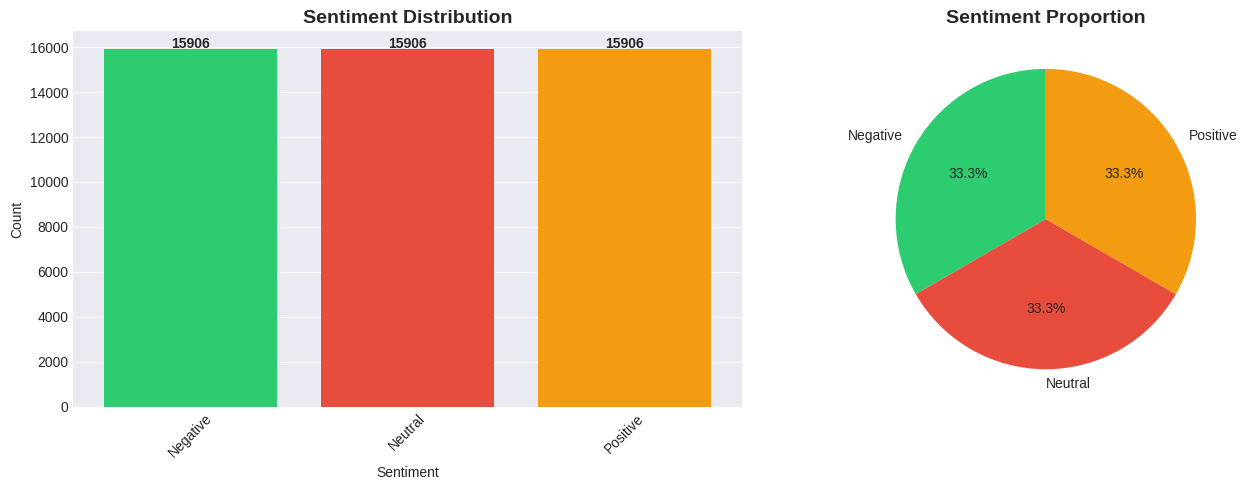

In [25]:
# ============================
# 3) Quick EDA
# ============================
print('Sentiment counts:\n', df['sentiment'].value_counts())
print('\nTopic counts:\n', df['topic_name'].value_counts())

df['text_len_words'] = df['full_text'].astype(str).apply(lambda s: len(s.split()))
print('\nText length (words) summary:\n', df['text_len_words'].describe())

# 3.1 Sentiment Distribution Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sentiment_counts = df['sentiment'].value_counts()
axes[0].bar(sentiment_counts.index, sentiment_counts.values,
            color=['#2ecc71', '#e74c3c', '#f39c12'])
axes[0].set_title('Sentiment Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(sentiment_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

axes[1].pie(
    sentiment_counts.values,
    labels=sentiment_counts.index,
    autopct='%1.1f%%',
    colors=['#2ecc71', '#e74c3c', '#f39c12'],
    startangle=90
)
axes[1].set_title('Sentiment Proportion', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()



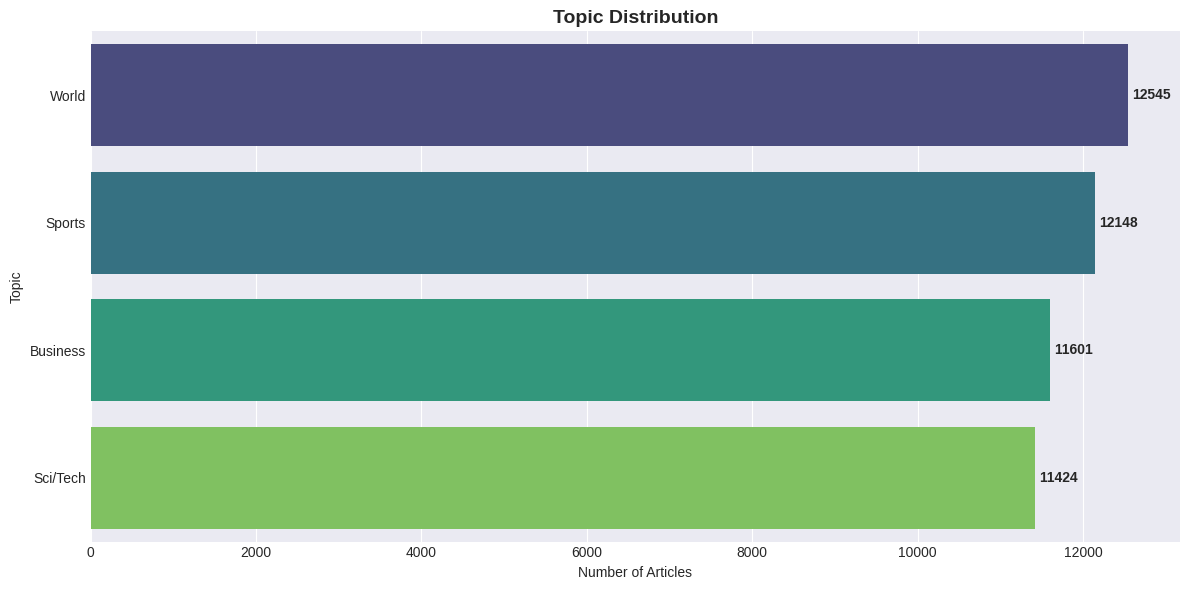

In [21]:
# 3.2 Topic Distribution
plt.figure(figsize=(12, 6))
topic_counts = df['topic_name'].value_counts()
sns.barplot(x=topic_counts.values, y=topic_counts.index, palette='viridis')
plt.title('Topic Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Number of Articles')
plt.ylabel('Topic')
for i, v in enumerate(topic_counts.values):
    plt.text(v + 50, i, str(v), va='center', fontweight='bold')
plt.tight_layout()
plt.show()



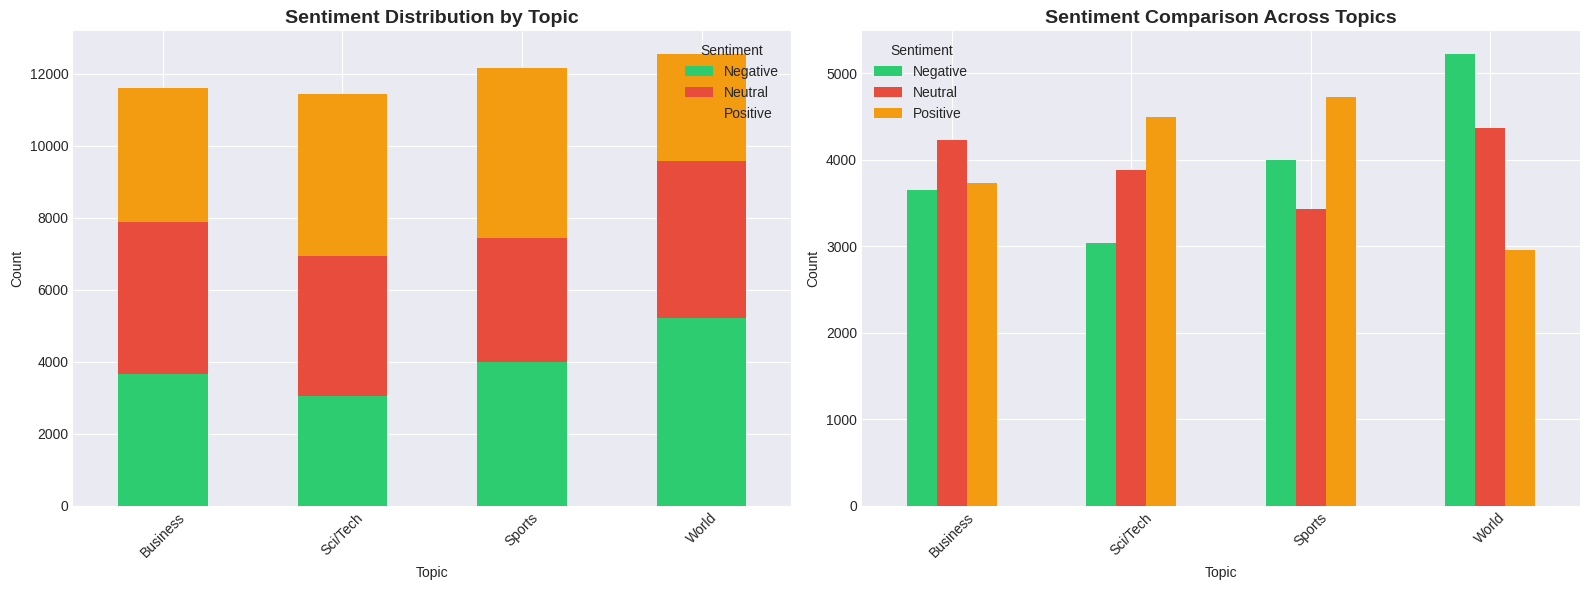

In [22]:
# 3.3 Sentiment by Topic
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sentiment_topic_ct = pd.crosstab(df['topic_name'], df['sentiment'])

sentiment_topic_ct.plot(
    kind='bar', stacked=True, ax=axes[0],
    color=['#2ecc71', '#e74c3c', '#f39c12']
)
axes[0].set_title('Sentiment Distribution by Topic', fontweight='bold', fontsize=14)
axes[0].set_xlabel('Topic')
axes[0].set_ylabel('Count')
axes[0].legend(title='Sentiment')
axes[0].tick_params(axis='x', rotation=45)

sentiment_topic_ct.plot(
    kind='bar', ax=axes[1],
    color=['#2ecc71', '#e74c3c', '#f39c12']
)
axes[1].set_title('Sentiment Comparison Across Topics', fontweight='bold', fontsize=14)
axes[1].set_xlabel('Topic')
axes[1].set_ylabel('Count')
axes[1].legend(title='Sentiment')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()



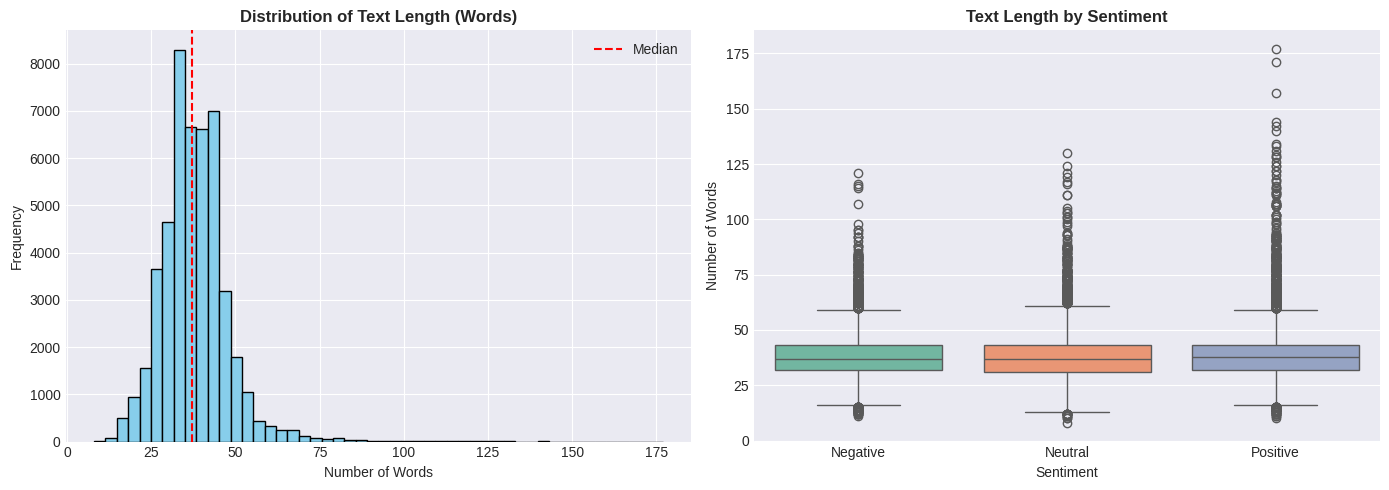

In [23]:
# 3.4 Text Length Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['text_len_words'], bins=50, color='skyblue', edgecolor='black')
axes[0].set_title('Distribution of Text Length (Words)', fontweight='bold')
axes[0].set_xlabel('Number of Words')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df['text_len_words'].median(), color='red',
                linestyle='--', label='Median')
axes[0].legend()

sns.boxplot(data=df, x='sentiment', y='text_len_words',
            palette='Set2', ax=axes[1])
axes[1].set_title('Text Length by Sentiment', fontweight='bold')
axes[1].set_xlabel('Sentiment')
axes[1].set_ylabel('Number of Words')

plt.tight_layout()
plt.show()


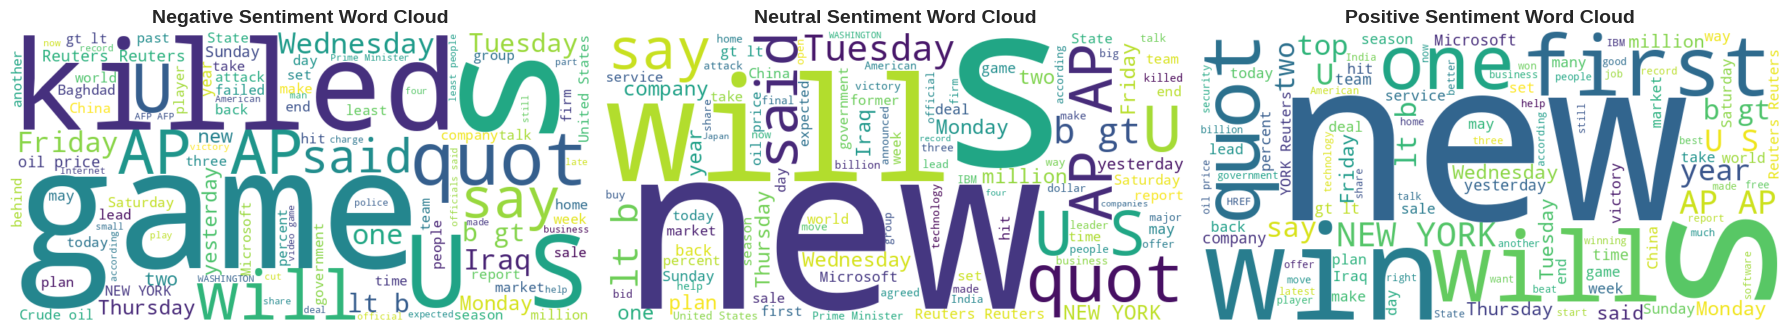

In [24]:
# 3.5 Word Clouds
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sentiments = ['Negative', 'Neutral', 'Positive']

for idx, sent in enumerate(sentiments):
    text_data = ' '.join(df[df['sentiment'] == sent]['full_text'].astype(str))
    wordcloud = WordCloud(
        width=800, height=400,
        background_color='white',
        colormap='viridis',
        max_words=100
    ).generate(text_data)
    axes[idx].imshow(wordcloud, interpolation='bilinear')
    axes[idx].set_title(f'{sent} Sentiment Word Cloud',
                        fontweight='bold', fontsize=14)
    axes[idx].axis('off')

plt.tight_layout()
plt.show()


# 4) Data quality + TextBlob


Missing Values Check:
text              0
label             0
topic_name        0
full_text         0
sentiment         0
text_len_words    0
dtype: int64

Data Types:
text              object
label              int64
topic_name        object
full_text         object
sentiment         object
text_len_words     int64
dtype: object

Duplicate Rows: 0

Rows after cleaning: 47718
TextBlob Sentiment Analysis Results:
           polarity  subjectivity
count  47718.000000  47718.000000
mean       0.011635      0.377702
std        0.235148      0.230363
min       -1.000000      0.000000
25%       -0.145823      0.225000
50%        0.000000      0.377273
75%        0.150000      0.500000
max        1.000000      1.000000

TextBlob Sentiment Distribution:
textblob_sentiment
Negative    15906
Neutral     15906
Positive    15906
Name: count, dtype: int64


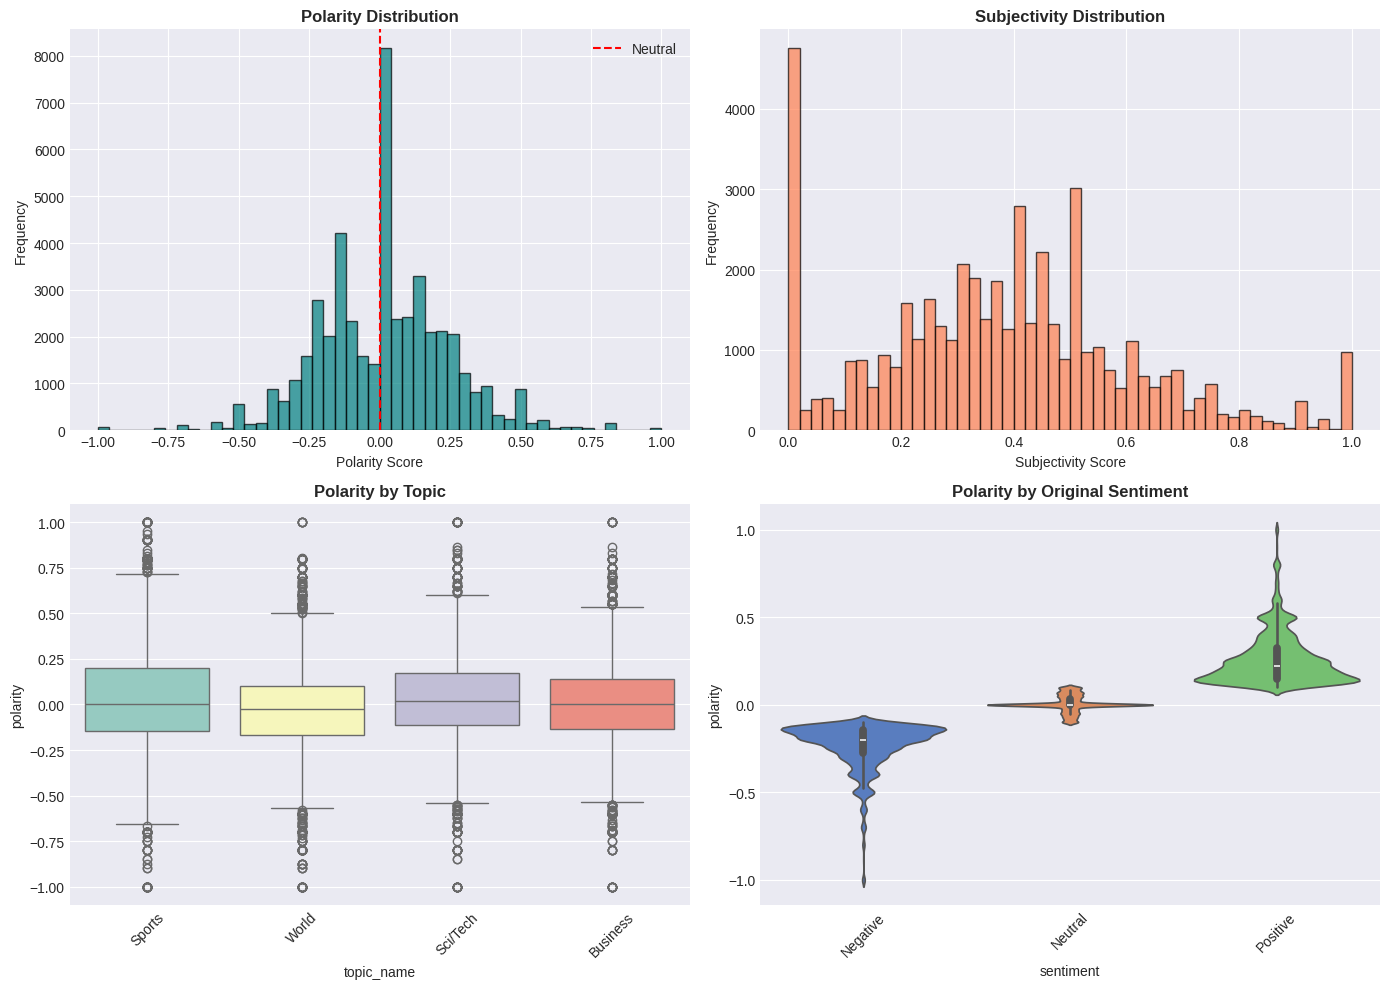

In [13]:
# ============================
# 4) Data quality + TextBlob
# ============================
print("Missing Values Check:")
print(df.isnull().sum())
print("\nData Types:")
print(df.dtypes)
print("\nDuplicate Rows:", df.duplicated().sum())

df = df.dropna(subset=['full_text', 'sentiment', 'topic_name'])
print(f"\nRows after cleaning: {len(df)}")

def analyze_sentiment_textblob(text):
    analysis = TextBlob(str(text))
    polarity = analysis.sentiment.polarity
    subjectivity = analysis.sentiment.subjectivity

    if polarity > 0.1:
        sentiment = 'Positive'
    elif polarity < -0.1:
        sentiment = 'Negative'
    else:
        sentiment = 'Neutral'
    return sentiment, polarity, subjectivity

df[['textblob_sentiment', 'polarity', 'subjectivity']] = df['full_text'].apply(
    lambda x: pd.Series(analyze_sentiment_textblob(x))
)

print("TextBlob Sentiment Analysis Results:")
print(df[['textblob_sentiment', 'polarity', 'subjectivity']].describe())
print("\nTextBlob Sentiment Distribution:")
print(df['textblob_sentiment'].value_counts())

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(df['polarity'], bins=50, color='teal', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Polarity Distribution', fontweight='bold')
axes[0, 0].set_xlabel('Polarity Score')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].axvline(0, color='red', linestyle='--', label='Neutral')
axes[0, 0].legend()

axes[0, 1].hist(df['subjectivity'], bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Subjectivity Distribution', fontweight='bold')
axes[0, 1].set_xlabel('Subjectivity Score')
axes[0, 1].set_ylabel('Frequency')

sns.boxplot(data=df, x='topic_name', y='polarity', palette='Set3', ax=axes[1, 0])
axes[1, 0].set_title('Polarity by Topic', fontweight='bold')
axes[1, 0].tick_params(axis='x', rotation=45)

sns.violinplot(data=df, x='sentiment', y='polarity', palette='muted', ax=axes[1, 1])
axes[1, 1].set_title('Polarity by Original Sentiment', fontweight='bold')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()



# 5) DistilBERT – Sentiment


In [14]:
# ============================
# 5) DistilBERT – Sentiment
# ============================
# نستخدم النص الأصلي للسنتمنت
sent_df = df[['full_text', 'sentiment']].copy()

train_df, test_df = train_test_split(
    sent_df,
    test_size=0.2,
    random_state=42,
    stratify=sent_df['sentiment']
)

print("Train size:", len(train_df))
print("Test size:", len(test_df))

label2id = {'Negative': 0, 'Neutral': 1, 'Positive': 2}
id2label = {v: k for k, v in label2id.items()}

model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

class SentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len: int = 256):
        self.texts = list(texts)
        self.labels = [label2id[l] for l in labels]
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text  = str(self.texts[idx])
        label = self.labels[idx]

        enc = self.tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt"
        )

        item = {k: v.squeeze(0) for k, v in enc.items()}
        item["labels"] = torch.tensor(label, dtype=torch.long)
        return item

train_dataset = SentimentDataset(
    texts=train_df["full_text"].values,
    labels=train_df["sentiment"].values,
    tokenizer=tokenizer
)

test_dataset = SentimentDataset(
    texts=test_df["full_text"].values,
    labels=test_df["sentiment"].values,
    tokenizer=tokenizer
)

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=-1)
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc}

batch_size = 16

training_args = TrainingArguments(
    output_dir="./distilbert_sentiment",
    learning_rate=2e-5,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    num_train_epochs=2,
    weight_decay=0.01
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)

trainer.train()
# بعد ما يخلص التدريب

# 🔹 حساب Training Accuracy للسنتمنت (BERT)
train_outputs = trainer.predict(train_dataset)       # يطلع لنا logits + labels
train_logits = train_outputs.predictions
train_labels = train_outputs.label_ids

train_preds = train_logits.argmax(axis=-1)          # ناخذ أعلى احتمال ككلاس متوقع
train_acc = accuracy_score(train_labels, train_preds)

print(f"[Sentiment-BERT] Training Accuracy: {train_acc:.4f}")

# 🔹 بعدها تقييم التست زي ما هو
metrics = trainer.evaluate()
print(metrics)
print("Test accuracy:", metrics.get("eval_accuracy", None))

metrics = trainer.evaluate()
print(metrics)
print("Test accuracy:", metrics.get("eval_accuracy", None))

trainer.save_model("./distilbert_sentiment_best")
tokenizer.save_pretrained("./distilbert_sentiment_best")



Train size: 38174
Test size: 9544


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Step,Training Loss
500,0.886900
1000,0.597500
1500,0.492300
2000,0.444400
2500,0.383800
3000,0.320200
3500,0.302000
4000,0.286600
4500,0.286500


[Sentiment-BERT] Training Accuracy: 0.9299


{'eval_loss': 0.32684606313705444, 'eval_accuracy': 0.8877829002514669, 'eval_runtime': 63.7951, 'eval_samples_per_second': 149.604, 'eval_steps_per_second': 9.358, 'epoch': 2.0}
Test accuracy: 0.8877829002514669
{'eval_loss': 0.32684606313705444, 'eval_accuracy': 0.8877829002514669, 'eval_runtime': 63.8085, 'eval_samples_per_second': 149.573, 'eval_steps_per_second': 9.356, 'epoch': 2.0}
Test accuracy: 0.8877829002514669


('./distilbert_sentiment_best/tokenizer_config.json',
 './distilbert_sentiment_best/special_tokens_map.json',
 './distilbert_sentiment_best/vocab.txt',
 './distilbert_sentiment_best/added_tokens.json',
 './distilbert_sentiment_best/tokenizer.json')

# 6) Text cleaning for topic model


In [15]:
# ============================
# 6) Text cleaning for topic model
# ============================
def clean_text(text: str) -> str:
    if text is None:
        return ''
    s = str(text)
    s = html.unescape(s)
    s = re.sub(r'http\S+|www\.[^\s]+', ' ', s)
    s = re.sub(r'<[^>]+>', ' ', s)
    s = unicodedata.normalize('NFKC', s)
    s = s.lower()
    s = re.sub(r'[^a-z0-9\s]', ' ', s)
    s = re.sub(r'\s+', ' ', s).strip()
    return s

df['text_clean'] = df['full_text'].astype(str).apply(clean_text)
print('Example cleaned text:\n', df['text_clean'].iloc[0][:300])



Example cleaned text:
 nfl game summary baltimore at cleveland cleveland oh sports network jeff garcia completed 15 of 24 passes for 180 yards including a 46 yard touchdown pass to quincy morgan leading cleveland over baltimore 20 3 in the season opener for both teams at cleveland browns stadium


# 7) Topic classifier (TF-IDF + LR)


In [16]:
# ============================
# 7) Topic classifier (TF-IDF + LR)
# ============================
def train_topic_classifier(texts, labels):
    X_train, X_test, y_train, y_test = train_test_split(
        texts,
        labels,
        test_size=0.2,
        random_state=42,
        stratify=labels
    )

    pipe = Pipeline([
        ('tfidf', TfidfVectorizer(
            max_features=30000,
            ngram_range=(1, 2),
            stop_words='english'
        )),
        ('clf', LogisticRegression(
            max_iter=1000,
            class_weight='balanced'
        ))
    ])

    pipe.fit(X_train, y_train)

    y_pred_train = pipe.predict(X_train)
    train_acc = accuracy_score(y_train, y_pred_train)
    print(f'\n[Topic] Training Accuracy: {train_acc:.4f}')

    y_pred_test = pipe.predict(X_test)
    test_acc = accuracy_score(y_test, y_pred_test)
    print(f'[Topic] Test Accuracy: {test_acc:.4f}')
    print(classification_report(y_test, y_pred_test))

    return pipe

topic_model = train_topic_classifier(df["text_clean"], df["topic_name"])


[Topic] Training Accuracy: 0.9505
[Topic] Test Accuracy: 0.9140
              precision    recall  f1-score   support

    Business       0.89      0.88      0.88      2320
    Sci/Tech       0.88      0.89      0.89      2285
      Sports       0.95      0.98      0.96      2430
       World       0.93      0.91      0.92      2509

    accuracy                           0.91      9544
   macro avg       0.91      0.91      0.91      9544
weighted avg       0.91      0.91      0.91      9544



# Confusion Matrices for Sentiment & Topic


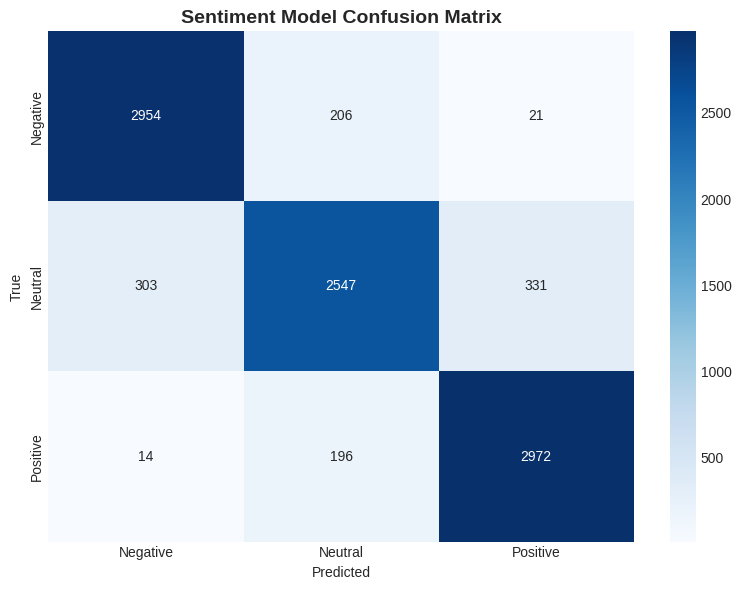

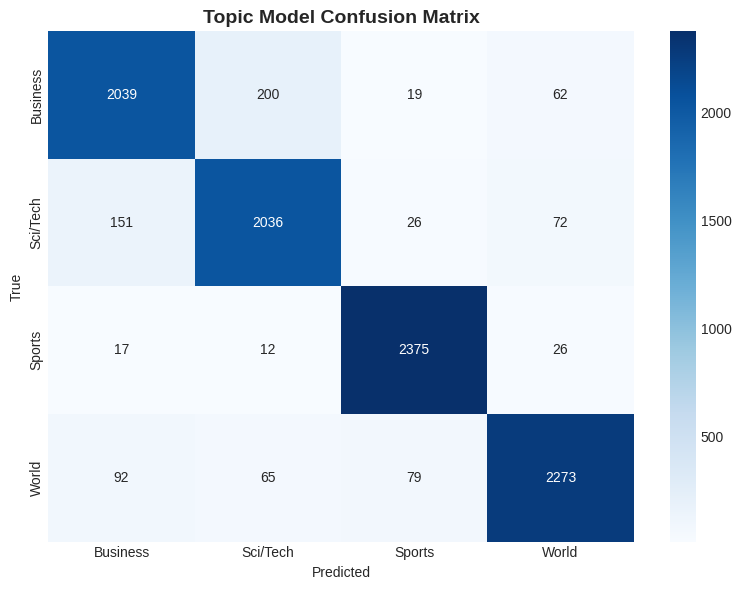

In [18]:
# ============================================
# Confusion Matrices for Sentiment & Topic
# ============================================
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# دالة رسم عامة
def plot_confusion_matrix(y_true, y_pred, labels, title):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=labels,
        yticklabels=labels
    )
    plt.title(title, fontweight='bold', fontsize=14)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    plt.show()
    return cm


# ========= 1) Confusion Matrix لموديل السنتمنت (DistilBERT) =========

# نستخدم نفس test_dataset اللي دربنا عليه الـ Trainer
pred_output = trainer.predict(test_dataset)
logits = pred_output.predictions        # شكلها (num_examples, num_labels)
labels_ids = pred_output.label_ids      # اللابلز الحقيقية (0/1/2)

# نجيب index أكبر logit = التوقع
pred_ids = logits.argmax(axis=-1)

# نحول الأرقام إلى أسماء الكلاسات باستخدام id2label
true_labels_sent = [id2label[int(i)] for i in labels_ids]
pred_labels_sent  = [id2label[int(i)] for i in pred_ids]

labels_sentiment = ["Negative", "Neutral", "Positive"]

cm_sentiment = plot_confusion_matrix(
    true_labels_sent,
    pred_labels_sent,
    labels_sentiment,
    "Sentiment Model Confusion Matrix"
)


# ========= 2) Confusion Matrix لموديل التوبيك (TF-IDF + LR) =========

# نرجع نسوي split للداتا حق التوبيك (نفس الإعدادات اللي فوق)
X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
    df["text_clean"],
    df["topic_name"],
    test_size=0.2,
    random_state=42,
    stratify=df["topic_name"]
)

# نستخدم topic_model اللي دربناه قبل شوي
y_pred_topic = topic_model.predict(X_test_t)

# ترتيب الليبلز حسب الموديل
labels_topic = list(topic_model.classes_)

cm_topic = plot_confusion_matrix(
    y_test_t,
    y_pred_topic,
    labels_topic,
    "Topic Model Confusion Matrix"
)


In [19]:
# ============================
# 8) Inference helpers
# ============================
import torch

# نختار الديفايس
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

# ---- 8.1 BERT Sentiment prediction ----
def predict_sentiment_bert(texts):
    """
    استخدم DistilBERT المدرب للتنبؤ بالسنتمنت
    """
    if isinstance(texts, str):
        texts = [texts]

    # نفس إعدادات التدريب تقريبًا
    enc = tokenizer(
        texts,
        truncation=True,
        padding=True,
        max_length=256,
        return_tensors="pt"
    )

    enc = {k: v.to(device) for k, v in enc.items()}

    with torch.no_grad():
        outputs = model(**enc)
        logits = outputs.logits
        preds = torch.argmax(logits, dim=-1).cpu().numpy()

    # نحول من أرقام إلى labels
    labels = [id2label[int(i)] for i in preds]
    return labels

# ---- 8.2 TF-IDF Topic prediction ----
def predict_topic_tfidf(texts):
    """
    استخدم موديل الـ TF-IDF + LogisticRegression للتنبؤ بالتوبيك
    """
    if isinstance(texts, str):
        texts = [texts]

    clean_texts = [clean_text(t) for t in texts]
    topic_preds = topic_model.predict(clean_texts)
    return topic_preds

# ---- 8.3 Combined helper ----
def predict_sentiment_and_topic(texts):
    """
    يعطيك السنتمنت (BERT) + التوبيك (TF-IDF) لنفس النص
    """
    if isinstance(texts, str):
        texts = [texts]

    sent_preds = predict_sentiment_bert(texts)
    topic_preds = predict_topic_tfidf(texts)

    return pd.DataFrame({
        "text": texts,
        "predicted_sentiment": sent_preds,
        "predicted_topic": topic_preds
    })

# ------- Demo -------
sample_texts = [
    "Tech giants unveil new AI chip with lower power consumption.",
    "Stocks rally as central bank signals pause on rate hikes.",
    "Local team secures dramatic win in championship final.",
    "Peace talks resume amid escalating tensions at the border."
]

result_df = predict_sentiment_and_topic(sample_texts)
print(result_df)


                                                text predicted_sentiment  \
0  Tech giants unveil new AI chip with lower powe...            Positive   
1  Stocks rally as central bank signals pause on ...             Neutral   
2  Local team secures dramatic win in championshi...            Positive   
3  Peace talks resume amid escalating tensions at...             Neutral   

  predicted_topic  
0        Sci/Tech  
1        Business  
2          Sports  
3           World  


In [20]:
import torch

# نختار الـ device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

# ---- 1) BERT Sentiment prediction ----
def predict_sentiment_bert(texts):
    if isinstance(texts, str):
        texts = [texts]

    enc = tokenizer(
        texts,
        truncation=True,
        padding=True,
        max_length=256,
        return_tensors="pt"
    )
    enc = {k: v.to(device) for k, v in enc.items()}

    with torch.no_grad():
        outputs = model(**enc)
        logits = outputs.logits
        preds = torch.argmax(logits, dim=-1).cpu().numpy()

    sent_labels = [id2label[int(i)] for i in preds]
    return sent_labels

# ---- 2) TF-IDF Topic prediction ----
def predict_topic_tfidf(texts):
    if isinstance(texts, str):
        texts = [texts]

    clean_texts = [clean_text(t) for t in texts]
    topic_preds = topic_model.predict(clean_texts)
    return topic_preds

# ---- 3) Enhanced: BERT + TextBlob + TF-IDF ----
def predict_sentiment_and_topic_enhanced(texts):
    if isinstance(texts, str):
        texts = [texts]

    # 🔹 موديل السنتمنت = BERT
    sent_preds = predict_sentiment_bert(texts)

    # 🔹 موديل التوبيك = TF-IDF + LR
    topic_preds = predict_topic_tfidf(texts)

    # 🔹 TextBlob (polarity + subjectivity + sentiment basline)
    textblob_results = [analyze_sentiment_textblob(t) for t in texts]
    textblob_sents = [r[0] for r in textblob_results]
    polarities = [r[1] for r in textblob_results]
    subjectivities = [r[2] for r in textblob_results]

    return pd.DataFrame({
        'text': texts,
        'predicted_sentiment': sent_preds,      # من BERT
        'textblob_sentiment': textblob_sents,   # من TextBlob
        'polarity': polarities,
        'subjectivity': subjectivities,
        'predicted_topic': topic_preds         # من TF-IDF
    })

# ------- Demo -------
sample_texts = [
    "Tech giants unveil new AI chip with lower power consumption.",
    "Stocks rally as central bank signals pause on rate hikes.",
    "Local team secures dramatic win in championship final.",
    "Peace talks resume amid escalating tensions at the border."
]

result_df = predict_sentiment_and_topic_enhanced(sample_texts)
print("\nEnhanced Prediction Results:")
print(result_df)



Enhanced Prediction Results:
                                                text predicted_sentiment  \
0  Tech giants unveil new AI chip with lower powe...            Positive   
1  Stocks rally as central bank signals pause on ...             Neutral   
2  Local team secures dramatic win in championshi...            Positive   
3  Peace talks resume amid escalating tensions at...             Neutral   

  textblob_sentiment  polarity  subjectivity predicted_topic  
0           Positive  0.136364      0.454545        Sci/Tech  
1            Neutral  0.000000      0.250000        Business  
2            Neutral  0.091667      0.500000          Sports  
3            Neutral  0.000000      0.000000           World  
